# Nepali News Corpus — exploratory data analysis

Dataset: [`himalaya-ai/nepali-news-corpus`](https://huggingface.co/datasets/himalaya-ai/nepali-news-corpus)

This notebook performs bounded, read-only EDA before the news corpus is admitted to pretraining. The public dataset viewer currently reports one `train` split, approximately 1.01 million rows, 18 Parquet shards, and the columns `id`, `text`, `url`, and `language`. Streaming keeps the initial exploration lightweight; every statistic below describes the sampled rows unless explicitly labelled otherwise.

In [1]:
from collections import Counter
from itertools import islice
from pathlib import Path
from urllib.parse import urlparse
import hashlib
import math
import re
import sys
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

DATASET_ID = "himalaya-ai/nepali-news-corpus"
SPLIT = "train"
SAMPLE_SIZE = 5_000
SHUFFLE_BUFFER = 20_000
SEED = 42
EXPECTED_COLUMNS = {"id", "text", "url", "language"}


/home/aixi/attentionMaps/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load a reproducible bounded sample

The streaming shuffle is approximate: it randomizes within a bounded buffer rather than globally shuffling all one million rows. This is appropriate for initial diagnostics, but final corpus statistics should be computed from downloaded Parquet shards.

In [2]:
stream = load_dataset(DATASET_ID, split=SPLIT, streaming=True)
sample_stream = stream.shuffle(seed=SEED, buffer_size=SHUFFLE_BUFFER)
rows = list(islice(sample_stream, SAMPLE_SIZE))

assert rows, "The dataset returned no rows."
missing = EXPECTED_COLUMNS - set(rows[0])
if missing:
    raise ValueError(f"Missing expected columns: {sorted(missing)}")

news_df = pd.DataFrame(rows)
print(f"Sampled rows: {len(news_df):,}")
print(f"Columns: {list(news_df.columns)}")
news_df.head(3)


Sampled rows: 5,000
Columns: ['id', 'text', 'url', 'language']


,id,text,url,language
0,0046226db04be3b882fa41cdb5c1576d,काठमाडौं । खिम्ति-ढल्केबर २२० केभी प्रसारण लाई...,https://bizmandu.com/content/30023.html,ne
1,e1a6e71f2a7cc6d1da8982d23a05a168,काठमाडौं। नेपाल उद्योग परिसंघका अध्यक्ष हरिभक्...,https://bizmandu.com/content/20190408170550.html,ne
2,5c1bcfe6d9333f1c81f1df1a56943e4c,एमालेले गर्याे तहका जनप्रतिनिधिका लागि दुईदिने...,https://maitrinews.com/2023/05/26/95717,ne


In [3]:
# Display five reproducible random records without truncating article text.
random_records = news_df.sample(n=min(5, len(news_df)), random_state=SEED)

for sample_number, (_, record) in enumerate(random_records.iterrows(), start=1):
    print("=" * 100)
    print(f"SAMPLE {sample_number}")
    for column in news_df.columns:
        print(f"{column}: {record[column]}")


SAMPLE 1
id: 7c0b46ce4a85e99870ccc7f34e698103
text: भारतीय गायकले पनि गाए ‘रेशम फिलिलि’को गीत ( )
मज्जाको अनलाइन, चैत्र २८ शनिवार २०७१, काठमाडौ ।
नेपाली चलचित्र नगरिमा फिल्म ‘रेशम फिलिली’को जालमा‘ बोलको यतिबेला चर्चाको शिखरमा छ । कालीप्रसाद बास्कोटाको संगीत रहेको यो गीतबाट प्रभावित भएर स्वदेश एवं विदेशमा बसेका नेपालीले निर्माण गर्ने र आफ्नै स्टाईलले गाउने क्रम जारी छ ।
सामाजिक संजाल युट्वियुमा अहिलेसम्म १९ लाख भन्दा बढी ‘हिट्स’ पाईसकेको यो गीतलाई पछिल्लो पटक भारतीय गायक- गायिकाले समेत ‘रिमिक्स’मा गाएका छन् । भारतीय गायक गौरभ दगोन्कार र उपासना क्षेत्रीले रेशम फिलिलि‘को रिमिक्स गाएको गायक गौरभले युटुबमार्फत् सार्वजनिक गरेका छन् ।
गीत भाइरल बनेपछि इन्टरनेटमा यसको नक्कल गर्ने र गीतमा थरीथरीका निर्माण गर्ने क्रम तिब्र छ । तर, निर्माण पक्षले यो गीतको वास्तविक भने अहिलेसम्म सार्वजनिक गरेको छैन् । यो गीतको हेर्न फिल्मको रिलिज मिति बैशाख ११ सम्म कुर्नुपर्ने भएको छ ।
गीतको बास्तविक हेर्नलाई बैशाख ११ सम्म कुर्नु परे पनि भारतीय गायक- गायिकाले गाएको ‘रिमिक्स’ चाँही कस्तो छ त ?
 हेर्रौ :
url: https:

## Text, script, and provenance diagnostics

The Devanagari ratio is computed over Unicode letters only, so punctuation, whitespace, and digits do not make a valid Nepali document look less Nepali. Latin characters are counted separately because news articles may legitimately contain names, acronyms, and technical terms.

In [4]:
def is_devanagari(character: str) -> bool:
    codepoint = ord(character)
    return (
        0x0900 <= codepoint <= 0x097F
        or 0xA8E0 <= codepoint <= 0xA8FF
        or 0x11B00 <= codepoint <= 0x11B5F
    )


def script_stats(text: str) -> tuple[float, int, int]:
    text = text if isinstance(text, str) else ""
    letters = [char for char in text if unicodedata.category(char).startswith("L")]
    devanagari = sum(is_devanagari(char) for char in letters)
    latin = sum("LATIN" in unicodedata.name(char, "") for char in letters)
    ratio = devanagari / len(letters) if letters else 0.0
    return ratio, devanagari, latin


def source_domain(url: str) -> str:
    if not isinstance(url, str) or not url.strip():
        return "<missing>"
    domain = urlparse(url).netloc.lower().split(":", 1)[0]
    return domain.removeprefix("www.") or "<invalid>"


def normalized_text_hash(text: str) -> str:
    normalized = unicodedata.normalize("NFC", text if isinstance(text, str) else "")
    normalized = re.sub(r"\s+", " ", normalized).strip()
    return hashlib.sha256(normalized.encode("utf-8")).hexdigest()


metrics = news_df.copy()
metrics["text"] = metrics["text"].fillna("").astype(str)
metrics["characters"] = metrics["text"].str.len()
metrics["utf8_bytes"] = metrics["text"].map(lambda text: len(text.encode("utf-8")))
metrics["whitespace_words"] = metrics["text"].map(lambda text: len(text.split()))
metrics["lines"] = metrics["text"].map(lambda text: len(text.splitlines()) or 1)
script_values = metrics["text"].map(script_stats)
metrics[["devanagari_ratio", "devanagari_letters", "latin_letters"]] = pd.DataFrame(
    script_values.tolist(), index=metrics.index
)
metrics["domain"] = metrics["url"].map(source_domain)
metrics["normalized_text_hash"] = metrics["text"].map(normalized_text_hash)
metrics.head(3)


,id,text,url,language,characters,utf8_bytes,whitespace_words,lines,devanagari_ratio,devanagari_letters,latin_letters,domain,normalized_text_hash
0,0046226db04be3b882fa41cdb5c1576d,काठमाडौं । खिम्ति-ढल्केबर २२० केभी प्रसारण लाई...,https://bizmandu.com/content/30023.html,ne,1777,4777,270,8,1.0,905,0,bizmandu.com,53b504df4276e0b6448b300460d8f76da902a03e0d3ad6...
1,e1a6e71f2a7cc6d1da8982d23a05a168,काठमाडौं। नेपाल उद्योग परिसंघका अध्यक्ष हरिभक्...,https://bizmandu.com/content/20190408170550.html,ne,1223,3333,168,4,1.0,643,0,bizmandu.com,e53239cccf2e3ae8a12bb504b77cfd9a8e2b16ac9c8f06...
2,5c1bcfe6d9333f1c81f1df1a56943e4c,एमालेले गर्याे तहका जनप्रतिनिधिका लागि दुईदिने...,https://maitrinews.com/2023/05/26/95717,ne,832,2248,117,8,1.0,436,0,maitrinews.com,756b77af5967c5f5ee20c81acf267d566112f62316550d...


In [5]:
quantiles = [0.0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0]
display(metrics[["characters", "utf8_bytes", "whitespace_words", "lines", "devanagari_ratio", "latin_letters"]].quantile(quantiles))

quality_summary = pd.Series({
    "sample_rows": len(metrics),
    "missing_or_blank_text": metrics["text"].str.strip().eq("").sum(),
    "missing_id": metrics["id"].isna().sum(),
    "duplicate_ids": metrics["id"].duplicated().sum(),
    "duplicate_normalized_texts": metrics["normalized_text_hash"].duplicated().sum(),
    "devanagari_ratio_below_0.80": metrics["devanagari_ratio"].lt(0.80).sum(),
    "contains_latin_letters": metrics["latin_letters"].gt(0).sum(),
    "unique_domains": metrics["domain"].nunique(),
})
display(quality_summary.to_frame("count"))
display(metrics["language"].value_counts(dropna=False).rename_axis("language").to_frame("rows"))
display(metrics["domain"].value_counts().head(20).rename_axis("domain").to_frame("rows"))


,characters,utf8_bytes,whitespace_words,lines,devanagari_ratio,latin_letters
0.00,209.00,267.00,29.00,1.0,0.000000,0.00
0.25,904.75,2158.75,141.00,5.0,0.936143,0.00
0.50,1401.50,3455.50,217.00,9.0,1.000000,0.00
0.75,2225.25,5462.25,347.25,21.0,1.000000,60.00
0.90,3766.40,8709.30,591.00,37.0,1.000000,558.20
0.95,4957.25,11553.50,780.05,47.0,1.000000,1425.10
0.99,8707.92,20791.05,1399.03,65.0,1.000000,5754.09
1.00,35557.00,95202.00,5408.00,375.0,1.000000,10689.00


,count
sample_rows,5000
missing_or_blank_text,0
missing_id,0
duplicate_ids,0
duplicate_normalized_texts,62
devanagari_ratio_below_0.80,631
contains_latin_letters,2414
unique_domains,86


,rows
language,
ne,4429
en,571


,rows
domain,
sansarnews.com,633
bizmandu.com,620
nepaliheadlines.com,560
karobardaily.com,283
bizkhabar.com,283
maitrinews.com,235
spotlightnepal.com,235
emailkhabar.com,228
mirmireonline.com,156


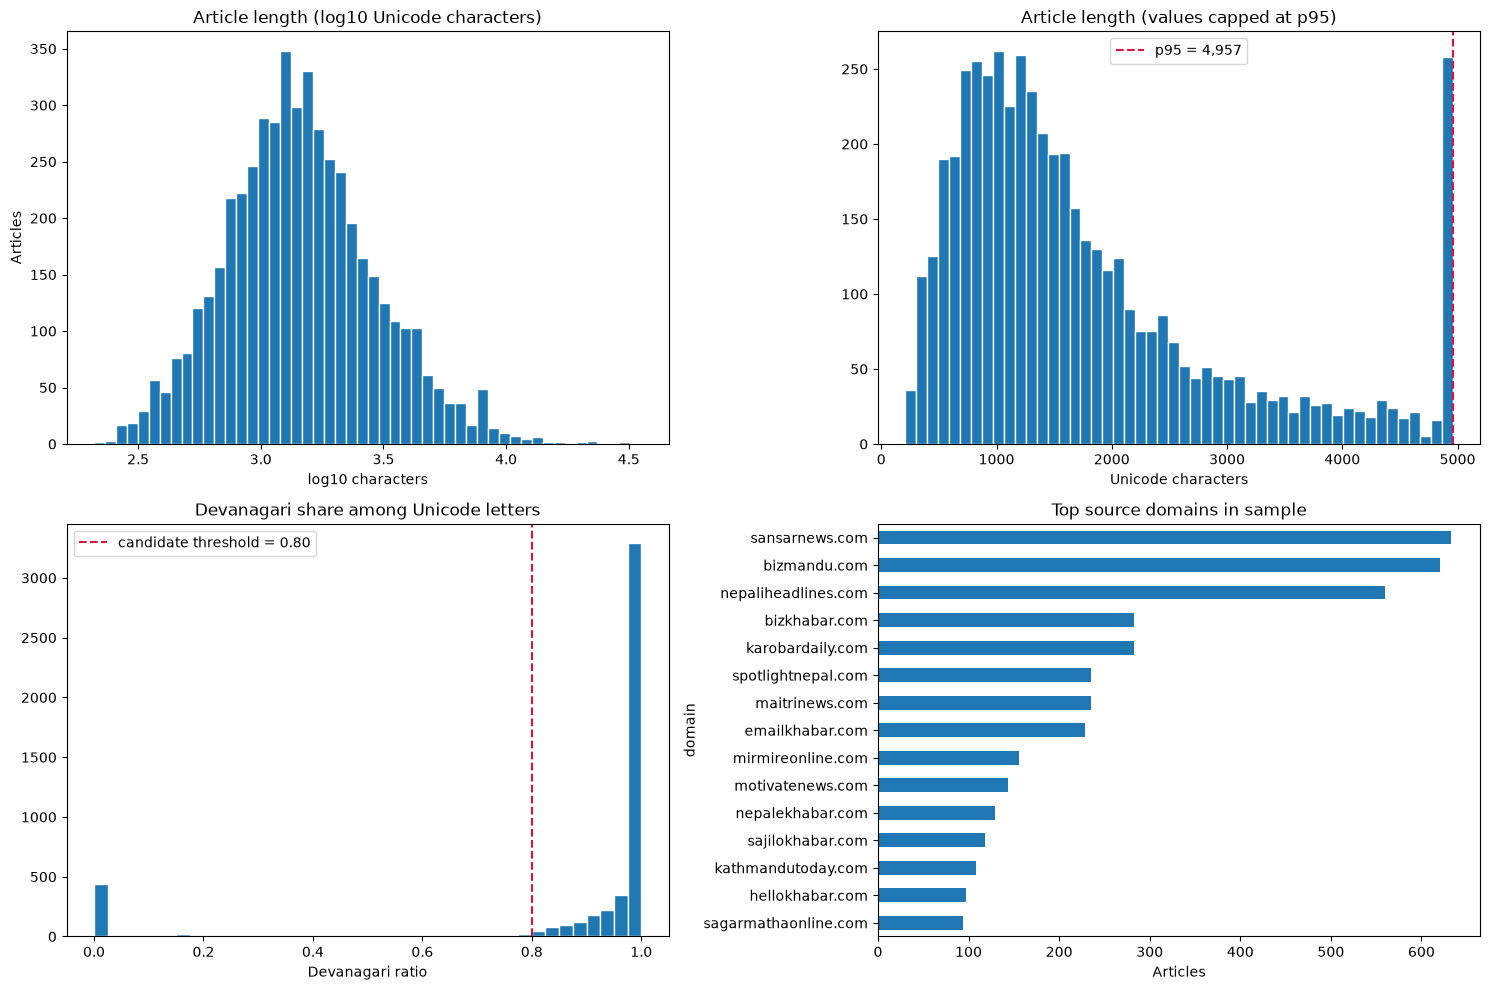

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(np.log10(metrics["characters"].clip(lower=1)), bins=50, edgecolor="white")
axes[0, 0].set_title("Article length (log10 Unicode characters)")
axes[0, 0].set_xlabel("log10 characters")
axes[0, 0].set_ylabel("Articles")

p95 = metrics["characters"].quantile(0.95)
axes[0, 1].hist(metrics["characters"].clip(upper=p95), bins=50, edgecolor="white")
axes[0, 1].axvline(p95, color="crimson", linestyle="--", label=f"p95 = {p95:,.0f}")
axes[0, 1].set_title("Article length (values capped at p95)")
axes[0, 1].set_xlabel("Unicode characters")
axes[0, 1].legend()

axes[1, 0].hist(metrics["devanagari_ratio"], bins=np.linspace(0, 1, 41), edgecolor="white")
axes[1, 0].axvline(0.80, color="crimson", linestyle="--", label="candidate threshold = 0.80")
axes[1, 0].set_title("Devanagari share among Unicode letters")
axes[1, 0].set_xlabel("Devanagari ratio")
axes[1, 0].legend()

top_domains = metrics["domain"].value_counts().head(15).sort_values()
top_domains.plot.barh(ax=axes[1, 1])
axes[1, 1].set_title("Top source domains in sample")
axes[1, 1].set_xlabel("Articles")

plt.tight_layout()
plt.show()


## Simulate repository cleaning

This cell compares the recommended `preserve` policy with strict Devanagari-only output. It does not modify the remote dataset. Exact deduplication should ultimately happen globally across all three corpora before train/validation/test assignment, preventing copied news or lyrics from leaking between splits.

In [7]:
def find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "scripts" / "utils" / "nepali_text.py").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the attentionMaps repository.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.utils.nepali_text import CleaningConfig, clean_text_with_result

preserve_config = CleaningConfig(mode="preserve", min_devanagari_ratio=0.80)
strict_config = CleaningConfig(mode="strict", min_devanagari_ratio=0.80)
preserve_results = metrics["text"].map(lambda text: clean_text_with_result(text, preserve_config))
strict_results = metrics["text"].map(lambda text: clean_text_with_result(text, strict_config))

cleaning_comparison = pd.DataFrame({
    "policy": ["preserve", "strict"],
    "accepted_rows": [sum(result.accepted for result in preserve_results), sum(result.accepted for result in strict_results)],
    "output_characters": [sum(len(result.text) for result in preserve_results), sum(len(result.text) for result in strict_results)],
})
cleaning_comparison["character_retention"] = cleaning_comparison["output_characters"] / metrics["characters"].sum()
display(cleaning_comparison)

rejection_reasons = Counter(result.reason or "accepted" for result in preserve_results)
display(pd.Series(rejection_reasons).sort_values(ascending=False).to_frame("rows"))


,policy,accepted_rows,output_characters,character_retention
0,preserve,4369,8001911,0.831705
1,strict,4369,7859478,0.816900


,rows
accepted,4369
low_ratio,631


## Three-corpus exploration status

The PDF and news datasets share a compatible document schema. The lyrics source should be profiled separately because song structure, repeated choruses, very short lines, and duplicate versions require different diagnostics. A `.crdownload` file is an incomplete browser download and must not be parsed or admitted to the corpus.

In [9]:
lyrics_root = REPO_ROOT / "data" / "nepali_lyrics"
partial_lyrics_downloads = sorted(lyrics_root.glob("*.crdownload")) if lyrics_root.exists() else []
completed_lyrics_files = sorted(
    path for path in lyrics_root.rglob("*")
    if path.is_file() and path.suffix.lower() != ".crdownload"
) if lyrics_root.exists() else []

corpus_status = pd.DataFrame([
    {"corpus": "Nepali PDF", "location": "data/raw/nepali_pdf_corpus", "status": "downloaded + EDA notebook", "next_check": "cross-corpus deduplication"},
    {"corpus": "Nepali news", "location": DATASET_ID, "status": f"streaming EDA sample ({len(news_df):,} rows)", "next_check": "full-shard statistics and source balance"},
    {"corpus": "Nepali lyrics", "location": str(lyrics_root), "status": f"{len(completed_lyrics_files)} complete files; {len(partial_lyrics_downloads)} partial downloads", "next_check": "wait for download, then inspect schema/format"},
])
display(corpus_status)

if partial_lyrics_downloads:
    print("Incomplete lyrics downloads (not analyzed):")
    for path in partial_lyrics_downloads:
        print(f"  {path.name}: {path.stat().st_size / 1024**3:.2f} GiB currently downloaded")


,corpus,location,status,next_check
0,Nepali PDF,data/raw/nepali_pdf_corpus,downloaded + EDA notebook,cross-corpus deduplication
1,Nepali news,himalaya-ai/nepali-news-corpus,"streaming EDA sample (5,000 rows)",full-shard statistics and source balance
2,Nepali lyrics,/home/aixi/attentionMaps/data/nepali_lyrics,0 complete files; 1 partial downloads,"wait for download, then inspect schema/format"


Incomplete lyrics downloads (not analyzed):
  Unconfirmed 130001.crdownload: 2.75 GiB currently downloaded


## Questions to answer before training

- Does a full-shard scan confirm the sample's length, script, and domain distributions?
- How much exact and near-duplicate news content exists within the corpus and across the PDF corpus?
- Are a few publisher domains overrepresented enough to require source caps or weighted sampling?
- Should mixed-script technical terms be preserved, while rejecting English-dominant articles at the document level?
- After the lyrics download completes, how much repetition is caused by choruses, alternate versions, or copied lyric pages?

Only after these checks should the three sources be normalized into a common provenance-aware schema and assigned document-level splits.